<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/projects/project_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Desafío de Clasificación — Predicción de Abandono de Clientes en ABC Multistate Bank

**Integrantes:** Miguel Ángel Nova · Martina Morales · Ivania Becerra
**Profesor:** Francisco Alfaro &nbsp;|&nbsp; **Asignatura:** Analítica para los Negocios I &nbsp;|&nbsp; Universidad Técnica Federico Santa María

## Descripción del Dataset y traducción de variables

El conjunto de datos (`bank.csv`) reúne información de **10.000 clientes** de ABC Multistate Bank. La tarea es predecir la variable objetivo `abandono` (1 = el cliente abandonó el banco, 0 = permaneció).

**Nota (a solicitud del profesor):** el dataset original está en inglés, así que **tradujimos todas las variables al español**. La columna del medio documenta la equivalencia que usamos en todo el análisis.

| Variable original (inglés) | Variable (español) | Descripción |
|---|---|---|
| `customer_id` | `id_cliente` | Identificador único del cliente (no se usa en el modelado) |
| `credit_score` | `puntaje_credito` | Puntaje crediticio |
| `country` | `país` | País (Francia, España, Alemania) |
| `gender` | `género` | Género (Femenino, Masculino) |
| `age` | `edad` | Edad |
| `tenure` | `antiguedad` | Años de relación con el banco |
| `balance` | `saldo` | Saldo de la cuenta |
| `products_number` | `numero_productos` | Número de productos contratados |
| `credit_card` | `tarjeta_credito` | Tiene tarjeta de crédito (1/0) |
| `active_member` | `miembro_activo` | Es miembro activo (1/0) |
| `estimated_salary` | `salario_estimado` | Salario anual estimado |
| `churn` | `abandono` | **Variable objetivo** (1 = abandonó, 0 = retenido) |

También tradujimos las categorías: **País** (France→Francia, Spain→España, Germany→Alemania) y **Género** (Female→Femenino, Male→Masculino).

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# --- Reproducibilidad ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Paleta institucional UTFSM (azul / amarillo / rojo, con variaciones) ---
USM_AZUL     = '#002B7F'   # azul institucional (primario)
USM_AMARILLO = '#F2B800'   # amarillo/dorado (secundario)
USM_ROJO     = '#CE1126'   # rojo (acento / riesgo)
USM_AZUL_CL  = '#4C6FB1'   # azul claro (variacion)
USM_GRIS     = '#8A8D91'   # gris neutro
ORO_OSC      = '#B8860B'   # dorado oscuro para lineas/texto sobre fondo claro
PALETA = [USM_AZUL, USM_AMARILLO, USM_ROJO, USM_AZUL_CL, USM_GRIS]

sns.set_theme(style='whitegrid')
sns.set_palette(PALETA)
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold', 'axes.titlesize': 12,
                     'axes.labelsize': 11, 'axes.labelweight': 'medium', 'figure.titleweight': 'bold'})
# Mapas de color institucionales para heatmaps
cmap_div = LinearSegmentedColormap.from_list('usm_div', [USM_AZUL, '#FFFFFF', USM_ROJO])   # divergente
cmap_seq = LinearSegmentedColormap.from_list('usm_seq', ['#FFFFFF', USM_AZUL])             # secuencial

# --- Carga de datos y traduccion al espanol ---
url = 'https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/projects/data/bank.csv'
df = pd.read_csv(url)
df = df.rename(columns={
    'customer_id': 'id_cliente', 'credit_score': 'puntaje_credito', 'country': 'país',
    'gender': 'género', 'age': 'edad', 'tenure': 'antiguedad', 'balance': 'saldo',
    'products_number': 'numero_productos', 'credit_card': 'tarjeta_credito',
    'active_member': 'miembro_activo', 'estimated_salary': 'salario_estimado', 'churn': 'abandono'})
df['país'] = df['país'].map({'France': 'Francia', 'Spain': 'España', 'Germany': 'Alemania'})
df['género'] = df['género'].map({'Female': 'Femenino', 'Male': 'Masculino'})

print('Dimensiones:', df.shape)
df.head()

Dimensiones: (10000, 12)


,id_cliente,puntaje_credito,país,género,edad,antiguedad,saldo,numero_productos,tarjeta_credito,miembro_activo,salario_estimado,abandono
0,15634602,619,Francia,Femenino,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,España,Femenino,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,Francia,Femenino,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,Francia,Femenino,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,España,Femenino,43,2,125510.82,1,1,1,79084.10,0


## 1. Introducción

Como **equipo de datos de ABC Multistate Bank**, enfrentamos un problema que preocupa a la dirección: un número creciente de clientes está cerrando sus cuentas. Este fenómeno —el *churn* o fuga de clientes— golpea al negocio por partida doble, porque no solo perdemos los ingresos que cada cliente generaba con sus productos, sino que además nos obliga a gastar más en marketing para captar reemplazos. Y captar un cliente nuevo es bastante más caro que conservar a uno que ya está: implica publicidad, promociones de bienvenida y todo el esfuerzo de construir una relación desde cero, mientras que retener suele requerir apenas una oferta oportuna o una atención más cercana.

La clave está en el **factor tiempo**. Si logramos identificar las señales de fuga *antes* de que el cliente concrete su salida, el banco puede actuar de forma preventiva y conservar la relación; si no, solo queda lamentar la pérdida cuando ya es irreversible. Anticiparse transforma un costo inevitable en una oportunidad de retención.

Por eso, nuestro **objetivo** es construir y comparar **cuatro modelos de clasificación** que predigan, a partir de la información de cada cliente (edad, país, número de productos, nivel de actividad, saldo, etc.), la probabilidad de que abandone el banco en el corto plazo. Más allá del desempeño puramente técnico, buscamos entregar al equipo de negocio una herramienta confiable para **identificar con anticipación a los clientes en riesgo**, entender **qué factores** pesan más en su decisión de irse y, sobre esa base, diseñar **acciones de retención concretas y medibles**.

## 2. Análisis Exploratorio de Datos (EDA)

### 2.1 Descripción general del dataset

In [2]:
# Estructura y calidad de los datos
print('Dimensiones:', df.shape)
print('Filas duplicadas:', df.duplicated().sum(),
      '| duplicadas sin id_cliente:', df.drop(columns='id_cliente').duplicated().sum())
print('Valores faltantes totales:', int(df.isna().sum().sum()))
df.dtypes.to_frame('tipo de dato')

Dimensiones: (10000, 12)
Filas duplicadas: 0 | duplicadas sin id_cliente: 0
Valores faltantes totales: 0


,tipo de dato
id_cliente,int64
puntaje_credito,int64
país,str
género,str
edad,int64
antiguedad,int64
saldo,float64
numero_productos,int64
tarjeta_credito,int64
miembro_activo,int64


In [3]:
# Resumen estadistico de las variables numericas
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
id_cliente,10000.0,15690940.57,71936.19,15565701.00,15628528.25,15690738.00,15753233.75,15815690.00
puntaje_credito,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
edad,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
antiguedad,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
saldo,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
numero_productos,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
tarjeta_credito,10000.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
miembro_activo,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
salario_estimado,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48
abandono,10000.0,0.20,0.40,0.00,0.00,0.00,0.00,1.00


El dataset reúne **10.000 clientes** descritos con **12 variables** y está **limpio de entrada**: no tiene filas duplicadas ni un solo valor faltante. De las 12 columnas, `id_cliente` es solo un identificador sin poder predictivo y `abandono` es la variable objetivo; las otras 10 son predictores que combinan información **demográfica** (edad, género, país), **financiera** (puntaje crediticio, saldo, salario) y de **relación con el banco** (antigüedad, número de productos, tarjeta y actividad).

Conviven cuatro tipos de variable: **continuas** (`saldo`, `salario_estimado`), **discretas** (`edad`, `antiguedad`, `numero_productos`), **binarias** (`tarjeta_credito`, `miembro_activo`) y **categóricas de texto** (`país`, `género`). Esto ya nos anticipa dos decisiones de preparación: tendremos que **codificar** las categóricas y **escalar** las numéricas antes de modelar.

### 2.2 Análisis univariado

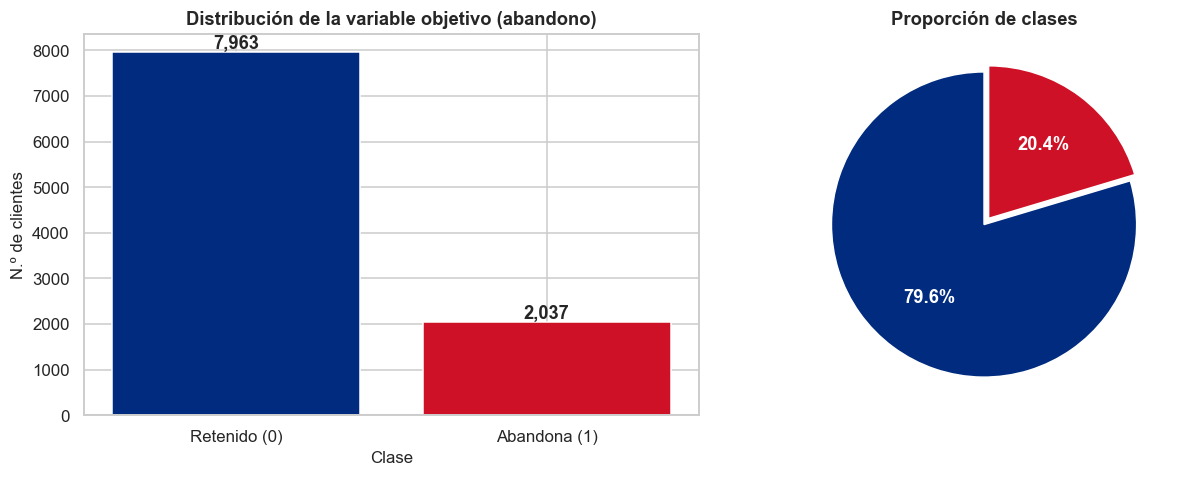

abandono
0    79.63 %
1    20.37 %
Name: proportion, dtype: str


In [4]:
# Variable objetivo: distribucion de clases
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
counts = df['abandono'].value_counts().sort_index()
ax[0].bar(['Retenido (0)', 'Abandona (1)'], counts.values, color=[USM_AZUL, USM_ROJO])
ax[0].set_title('Distribución de la variable objetivo (abandono)')
ax[0].set_xlabel('Clase'); ax[0].set_ylabel('N.º de clientes')
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 80, f'{v:,}', ha='center', fontweight='bold')
ax[1].pie(counts.values, labels=['Retenido', 'Abandona'], autopct='%1.1f%%',
          colors=[USM_AZUL, USM_ROJO], startangle=90, explode=(0, 0.05),
          textprops={'color': 'white', 'fontweight': 'bold'})
ax[1].set_title('Proporción de clases')
plt.tight_layout(); plt.show()
print((df['abandono'].value_counts(normalize=True) * 100).round(2).astype(str) + ' %')

Encontramos un **marcado desbalance**: el **79,6 %** de los clientes permanece y solo el **20,4 %** abandona (proporción cercana a 1:4). Este es un hallazgo determinante para todo el proyecto, porque la clase que nos interesa —los que se van— es la minoritaria. Por eso **la *accuracy* no nos sirve como métrica**: un modelo que dijera "nadie se va" acertaría el 80 % sin aportar ningún valor. En consecuencia, priorizaremos **ROC-AUC, precisión, recall y F1**, y trataremos el desbalance con **ponderación de clases** (`class_weight`) más un **ajuste de umbral** (Sección 6), en lugar de generar datos sintéticos.

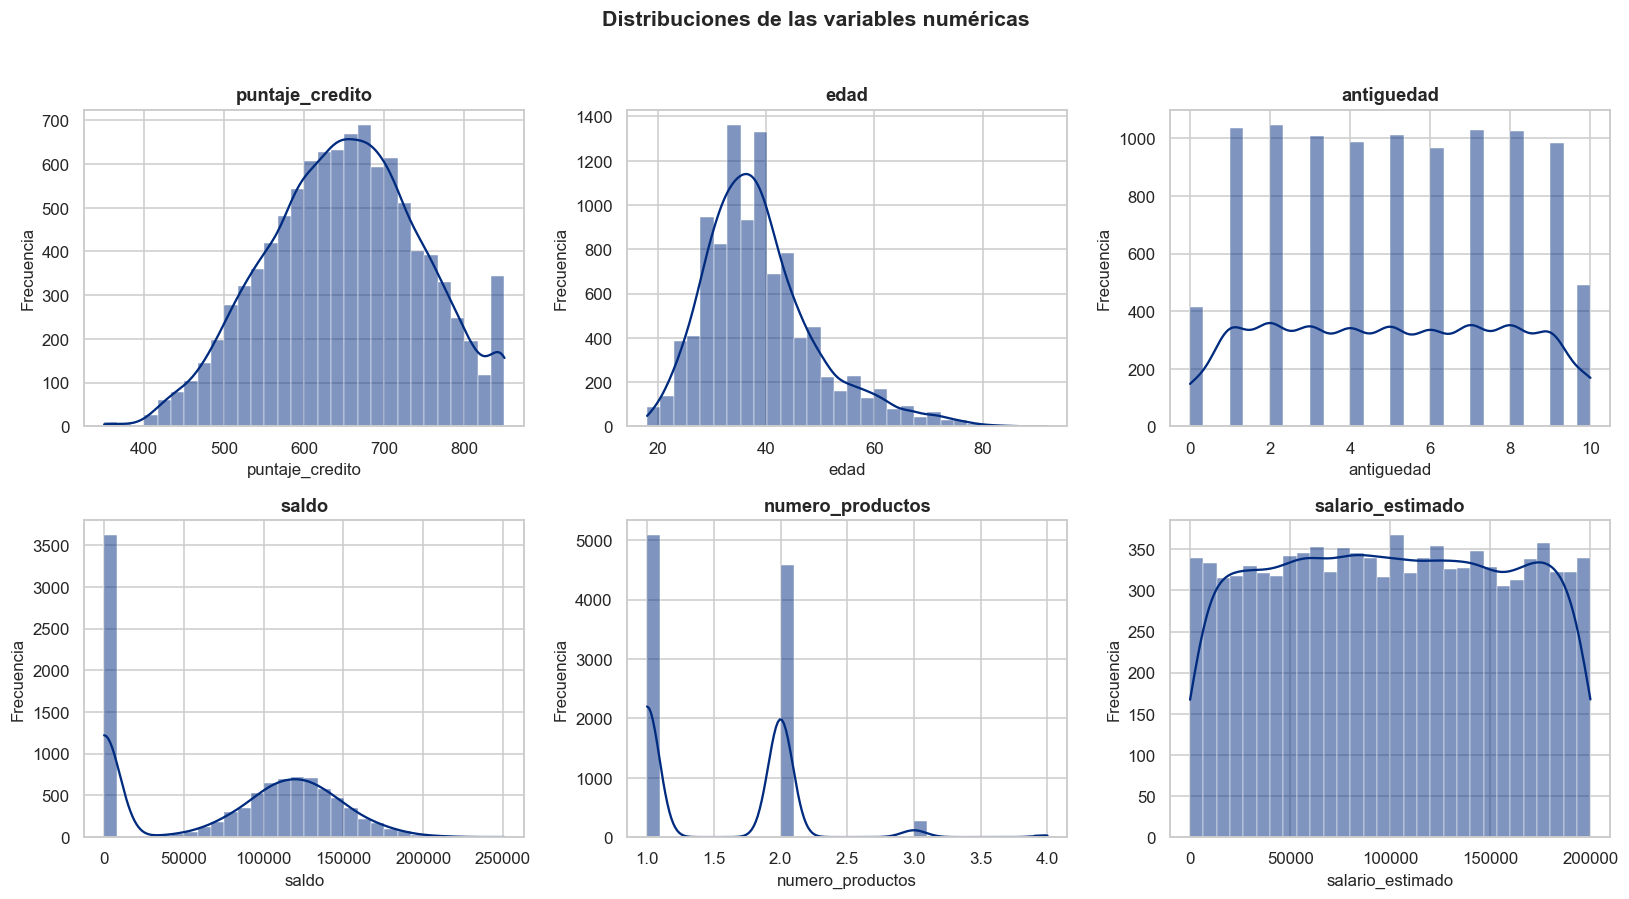

Clientes con saldo 0: 3617


In [5]:
# Distribuciones de las variables numericas
num_cols = ['puntaje_credito', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'salario_estimado']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=ax, color=USM_AZUL, edgecolor='white', linewidth=.3)
    ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel('Frecuencia')
plt.suptitle('Distribuciones de las variables numéricas', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()
print('Clientes con saldo 0:', int((df['saldo'] == 0).sum()))

Los histogramas muestran comportamientos bien diferenciados:

- **`puntaje_credito`**: aproximadamente simétrico en torno a 650, con una leve cola hacia valores bajos.
- **`edad`**: claro **sesgo positivo** —la mayoría entre 30 y 40 años— con una cola larga hacia edades mayores que anticipa algunos valores atípicos por arriba.
- **`antiguedad`**: prácticamente **uniforme** entre 1 y 9 años, con menos casos en los extremos 0 y 10.
- **`saldo`**: patrón **bimodal**, con un grupo grande de clientes de **saldo cero** (unos 3.617) y el resto repartido de forma casi normal en torno a 100.000–125.000.
- **`numero_productos`**: la gran mayoría tiene **1 o 2 productos**; 3 es poco frecuente y 4 excepcional.
- **`salario_estimado`**: **uniforme** en todo su rango, lo que anticipa poca capacidad de discriminación por sí solo.

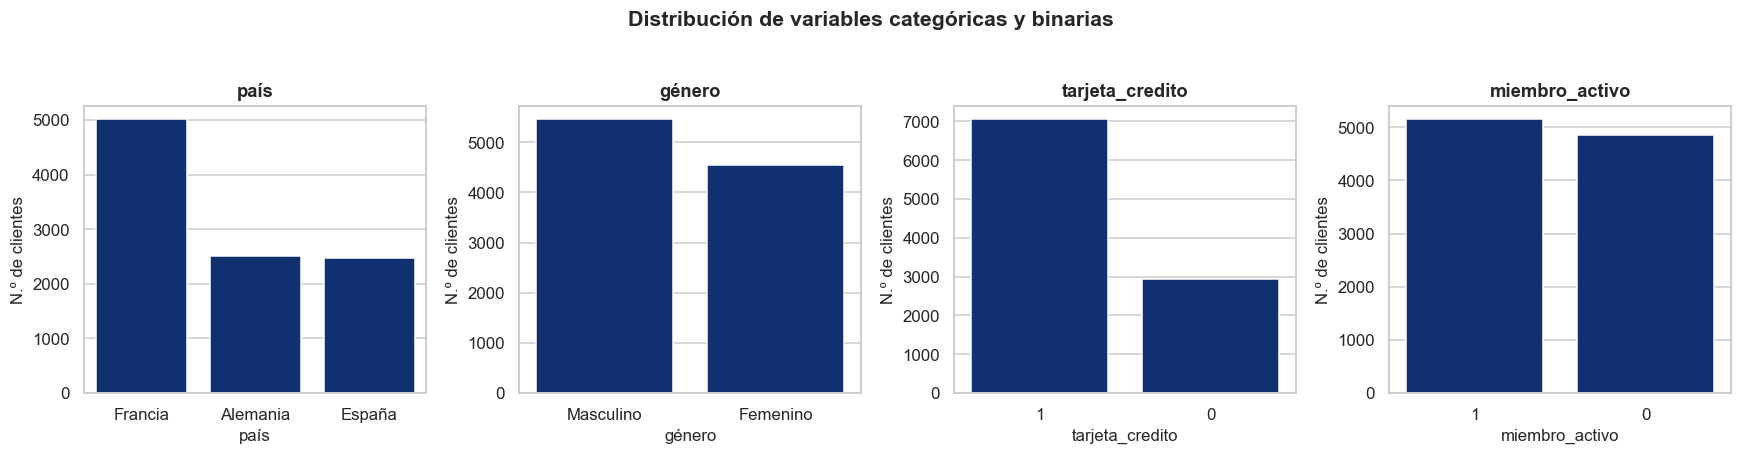

In [6]:
# Proporciones de las variables categoricas y binarias
cat_cols = ['país', 'género', 'tarjeta_credito', 'miembro_activo']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes.ravel(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, color=USM_AZUL)
    ax.set_title(col); ax.set_xlabel(col); ax.set_ylabel('N.º de clientes')
plt.suptitle('Distribución de variables categóricas y binarias', y=1.03, fontsize=14)
plt.tight_layout(); plt.show()

En las categóricas: **Francia** concentra cerca de la mitad de los clientes, mientras que **España** y **Alemania** se reparten el resto casi por igual; hay **algo más de hombres que de mujeres**; alrededor del **70 %** posee tarjeta de crédito y los **miembros activos** son cerca de la mitad de la cartera. Ninguna categoría está tan desbalanceada como para descartarla; el reparto entre países será relevante más adelante, cuando analicemos el abandono por geografía.

### 2.3 Análisis bivariado (cada predictor frente al abandono)

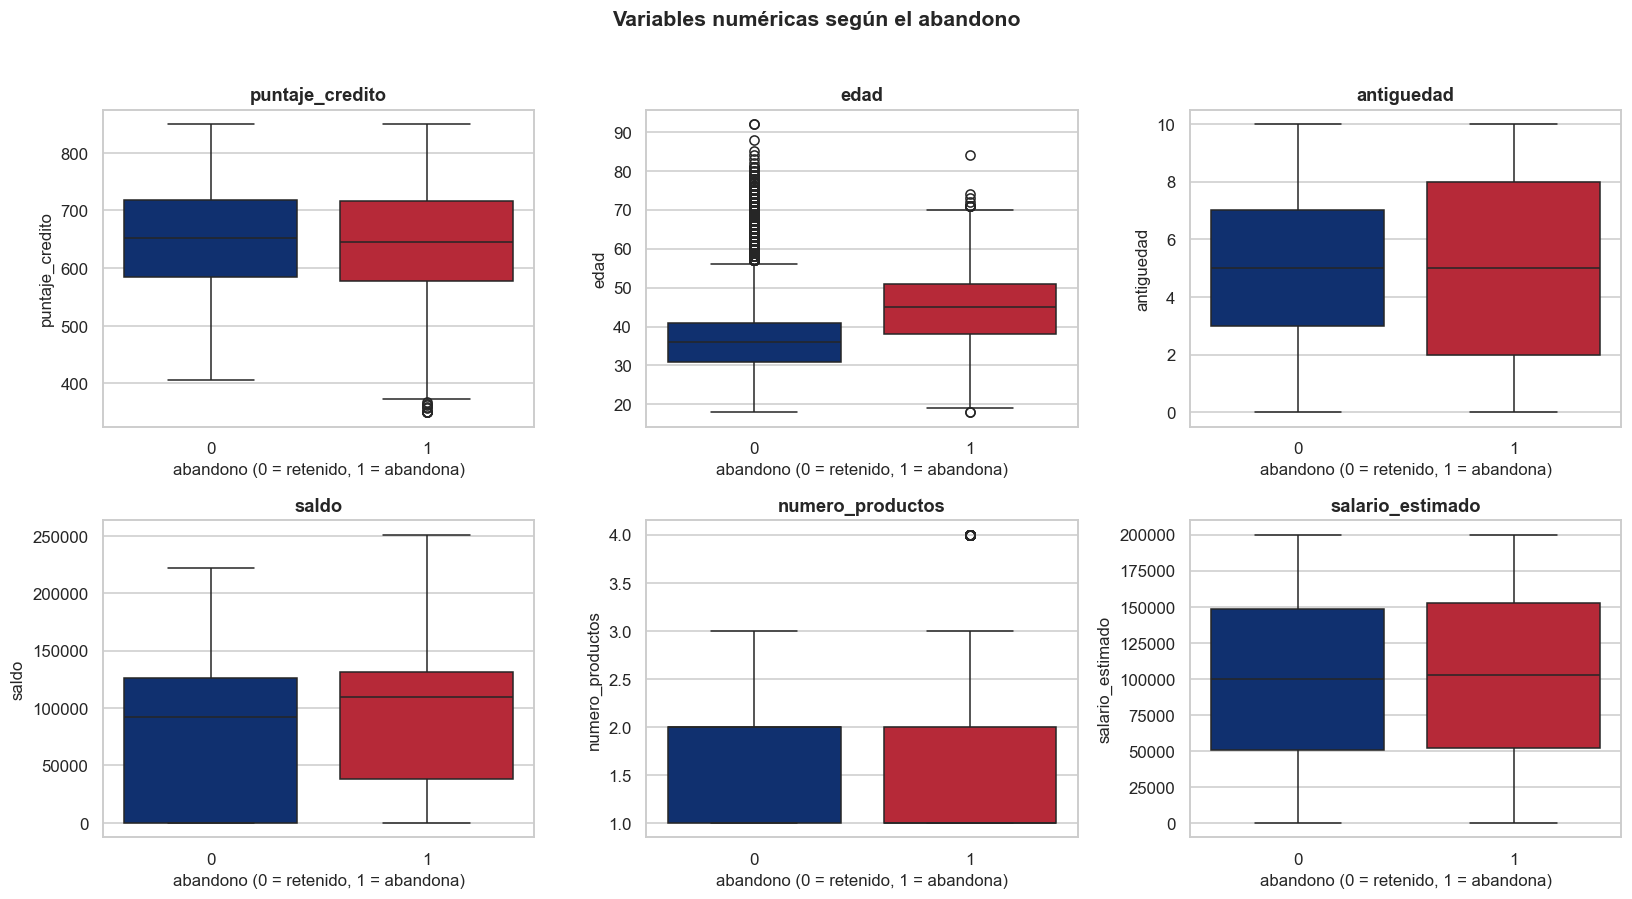

In [7]:
# Variables numericas segun abandono
num_cols = ['puntaje_credito', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'salario_estimado']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x='abandono', y=col, hue='abandono', legend=False,
                ax=ax, palette=[USM_AZUL, USM_ROJO])
    ax.set_title(col); ax.set_xlabel('abandono (0 = retenido, 1 = abandona)'); ax.set_ylabel(col)
plt.suptitle('Variables numéricas según el abandono', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

In [8]:
# Promedio de cada variable numerica por grupo, con la diferencia
resumen = df.groupby('abandono')[num_cols].mean().T
resumen.columns = ['Retenido (0)', 'Abandona (1)']
resumen['Diferencia'] = resumen['Abandona (1)'] - resumen['Retenido (0)']
resumen.round(1)

,Retenido (0),Abandona (1),Diferencia
puntaje_credito,651.9,645.4,-6.5
edad,37.4,44.8,7.4
antiguedad,5.0,4.9,-0.1
saldo,72745.3,91108.5,18363.2
numero_productos,1.5,1.5,-0.1
salario_estimado,99738.4,101465.7,1727.3


La **edad** se confirma como el predictor más discriminante: quienes abandonan promedian **44,8 años** frente a **37,4** de quienes se quedan. El **saldo** también es mayor en los que se van (**91.109** vs **72.745**); a primera vista sorprende, pero se explica porque el gran grupo de saldo cero —en su mayoría retenidos— arrastra hacia abajo el promedio de los que permanecen, de modo que un **saldo alto combinado con inactividad** configura un perfil de riesgo. En cambio, `puntaje_credito` y `salario_estimado` son **casi idénticos** entre ambos grupos: aportan poco por sí solos. Ojo con `numero_productos`: su promedio es 1,5 en ambos grupos, pero eso **esconde una relación no lineal** que revelamos mejor con la tasa de abandono por categoría.

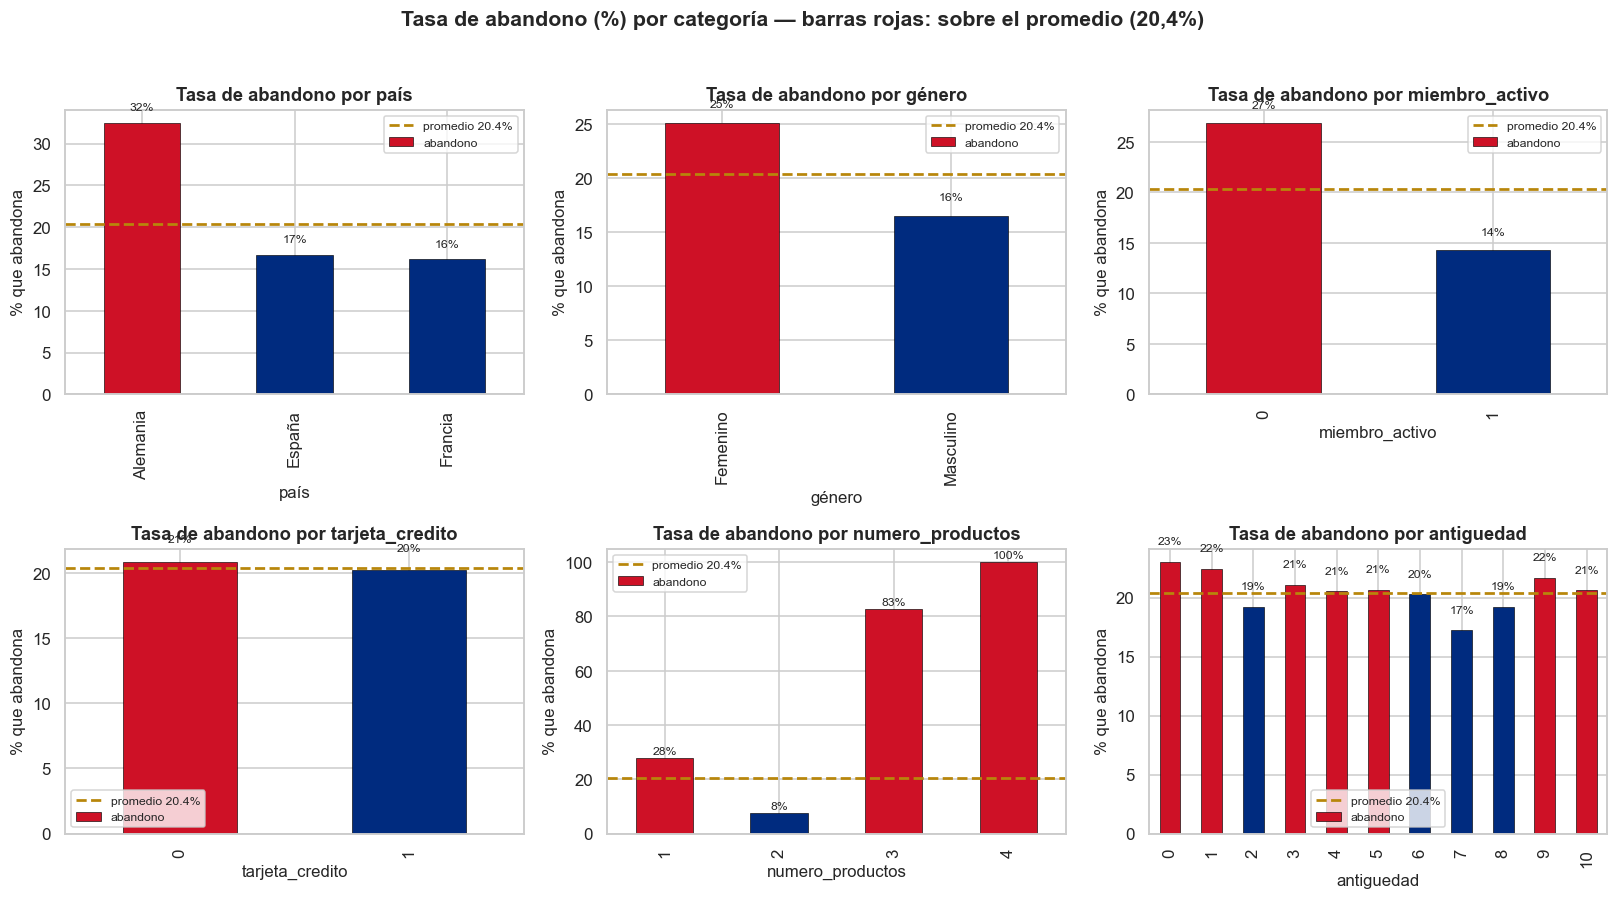

In [9]:
# Tasa de abandono (%) por categoria: aqui esta la historia del dataset
cat_cols = ['país', 'género', 'miembro_activo', 'tarjeta_credito', 'numero_productos', 'antiguedad']
base = df['abandono'].mean() * 100
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    tasa = df.groupby(col)['abandono'].mean() * 100
    colores = [USM_ROJO if v > base else USM_AZUL for v in tasa.values]   # rojo = sobre el promedio (riesgo)
    tasa.plot(kind='bar', ax=ax, color=colores, edgecolor='black', linewidth=.4)
    ax.axhline(base, color=ORO_OSC, ls='--', lw=1.8, label=f'promedio {base:.1f}%')
    ax.set_title(f'Tasa de abandono por {col}'); ax.set_ylabel('% que abandona'); ax.set_xlabel(col)
    ax.legend(fontsize=8)
    for i, v in enumerate(tasa.values):
        ax.text(i, v + 1.5, f'{v:.0f}%', ha='center', fontsize=8)
plt.suptitle('Tasa de abandono (%) por categoría — barras rojas: sobre el promedio (20,4%)', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

Las **tasas de abandono por categoría** son lo más revelador del EDA (marcamos en **rojo** las categorías sobre el promedio):

- **País:** **Alemania duplica el abandono** (**32,4 %**) frente a Francia (16,2 %) y España (16,7 %).
- **Número de productos:** relación **fuertemente no lineal** — con 2 productos el abandono cae al mínimo (**7,6 %**), pero salta a **82,7 % con 3 productos y 100 % con 4**. Es la señal más potente del dataset, y anticipamos que **ningún modelo lineal la capturará bien**: será el argumento a favor de los modelos de árbol.
- **Actividad:** los **miembros inactivos** abandonan casi el doble (**26,9 %**) que los activos (**14,3 %**).
- **Género:** las **mujeres** se van más (**25,1 %**) que los hombres (**16,5 %**).
- **Tarjeta y antigüedad:** prácticamente **sin efecto** (todas las barras pegadas al promedio).

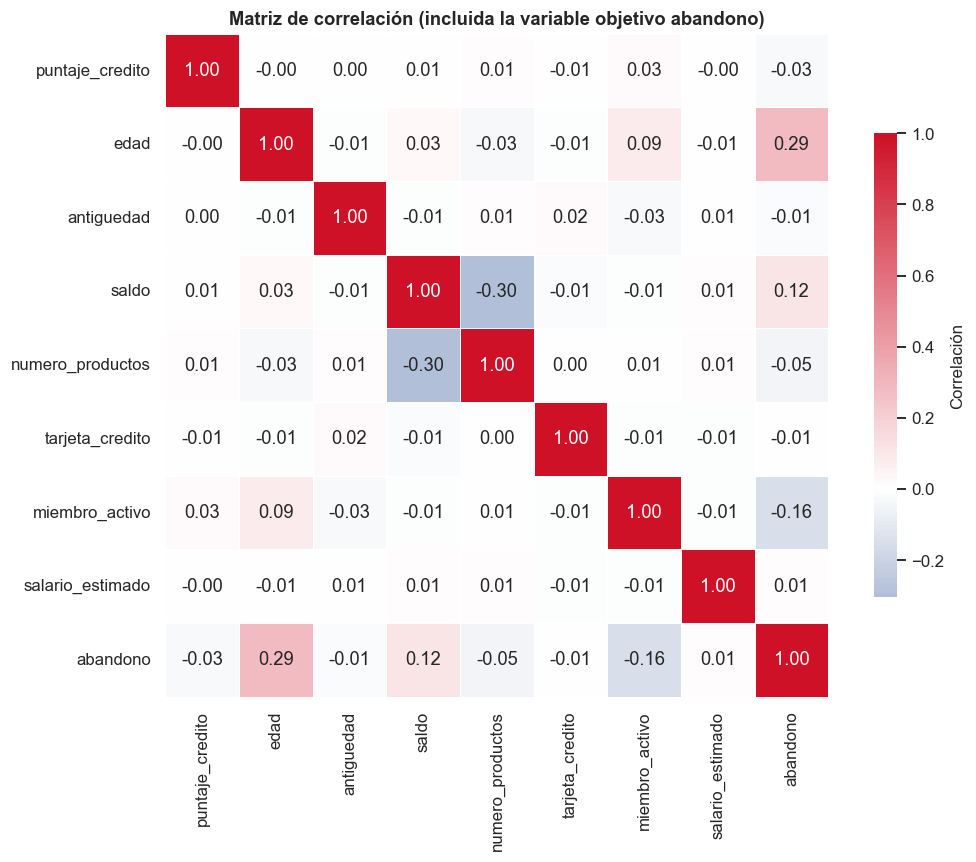

In [10]:
# Matriz de correlacion incluyendo la variable objetivo
cols_corr = ['puntaje_credito', 'edad', 'antiguedad', 'saldo', 'numero_productos',
             'tarjeta_credito', 'miembro_activo', 'salario_estimado', 'abandono']
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_corr].corr(), annot=True, fmt='.2f', cmap=cmap_div,
            center=0, square=True, linewidths=.5, cbar_kws={'shrink': .7, 'label': 'Correlación'})
plt.title('Matriz de correlación (incluida la variable objetivo abandono)')
plt.tight_layout(); plt.show()

La matriz respalda numéricamente lo anterior. Respecto al abandono, la **edad** tiene la correlación positiva más fuerte (≈ **0,29**), seguida del **saldo** (≈ 0,12); en sentido inverso, ser **miembro activo** es el factor protector más marcado (≈ **−0,16**). El resto de las variables tiene correlaciones casi nulas, lo que reafirma que puntaje crediticio, antigüedad, tarjeta y salario aportan poco de forma individual. Entre predictores destaca una correlación negativa moderada entre **saldo y número de productos** (≈ **−0,30**), la relación más notable del conjunto. Nota metodológica: la correlación de Pearson solo captura relaciones **lineales**, por eso `numero_productos` aparece débil aquí pese a ser clave —su efecto es no lineal, como vimos en las tasas de abandono.

### 2.4 Detección de valores atípicos (IQR / z-score)

In [11]:
# Outliers por IQR y por z-score (|z|>3) para cada variable numerica
def resumen_outliers(s):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask_iqr = (s < low) | (s > high)
    z = ((s - s.mean()) / s.std()).abs()
    return pd.Series({'Lím. inferior': round(low, 1), 'Lím. superior': round(high, 1),
                      'Outliers (IQR)': int(mask_iqr.sum()), '% del total': round(mask_iqr.mean() * 100, 2),
                      'Outliers (|z|>3)': int((z > 3).sum())})

tabla_out = df[num_cols].apply(resumen_outliers).T.sort_values('Outliers (IQR)', ascending=False)
tabla_out

,Lím. inferior,Lím. superior,Outliers (IQR),% del total,Outliers (|z|>3)
edad,14.0,62.0,359.0,3.59,133.0
numero_productos,-0.5,3.5,60.0,0.60,60.0
puntaje_credito,383.0,919.0,15.0,0.15,8.0
antiguedad,-3.0,13.0,0.0,0.00,0.0
saldo,-191466.4,319110.6,0.0,0.00,0.0
salario_estimado,-96577.1,296967.5,0.0,0.00,0.0


El dataset tiene **muy pocos valores atípicos**. La variable con más es la **edad**, con **359 casos (3,59 %)**: clientes mayores cuyo rango válido según IQR llega hasta los 62 años, de modo que los outliers corresponden a personas de **63 a 92 años**. Le siguen, marginalmente, `numero_productos` (**60**; 0,60 %) y `puntaje_credito` (**15**; 0,15 %). Las variables `antiguedad`, `saldo` y `salario_estimado` **no presentan ningún outlier** por este criterio, y el z-score (|z|>3) confirma el mismo patrón.

### 2.5 Decisiones de tratamiento

Con el EDA cerrado, tomamos y justificamos las siguientes decisiones antes de modelar:

- **Valores faltantes → no imputamos nada.** El dataset no tiene un solo valor nulo (lo verificamos en 2.1), así que no hay imputación que hacer. Es un dato limpio de origen.

- **Valores atípicos → los conservamos.** Los outliers de edad **no son errores de registro**, sino clientes reales de edad avanzada (63–92 años), un segmento plenamente legítimo y —como vimos en el bivariado— **precisamente el de mayor propensión al abandono**. Eliminarlos nos haría perder justo la información más valiosa para predecir la fuga. Descartamos también la winsorización por el mismo motivo. Además, los modelos de árbol que usaremos (Random Forest, Gradient Boosting) son **robustos frente a outliers** por naturaleza.

- **Variables a eliminar o transformar:**
  - Eliminamos **`id_cliente`**: es un identificador único, no aporta poder predictivo y solo introduciría ruido.
  - **Codificaremos** `país` y `género` (One-Hot Encoding) por ser categóricas de texto.
  - **Escalaremos** las numéricas para los modelos sensibles a la magnitud (regresión logística).
  - La relación **no lineal** de `numero_productos` con el abandono justifica incluir modelos de árbol, capaces de capturarla, además del baseline lineal.

## 3. Preparación de los Datos

Tras validar la calidad de los datos en el EDA, los acondicionamos para el modelado cuidando dos riesgos clásicos: la **fuga de datos** (*data leakage*) y el **desbalance de clases**.

### 3.1 Separación de predictores y división train/test estratificada

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['id_cliente', 'abandono'])   # quitamos el ID (sin poder predictivo)
y = df['abandono']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print(f'Train: {X_train.shape[0]:,} clientes | Test: {X_test.shape[0]:,} clientes')
prop = pd.DataFrame({'Train': y_train.value_counts(normalize=True),
                     'Test':  y_test.value_counts(normalize=True)}).mul(100).round(2)
prop.index = ['Retenido (0)', 'Abandona (1)']
prop

Train: 8,000 clientes | Test: 2,000 clientes


,Train,Test
Retenido (0),79.62,79.65
Abandona (1),20.38,20.35


Dividimos en **80 % entrenamiento (8.000) y 20 % prueba (2.000)** con muestreo **estratificado**: así la proporción de fuga se mantiene idéntica (~20,4 %) en ambos conjuntos. Sin estratificar, correríamos el riesgo de entrenar o evaluar sobre una distribución irreal de clientes en fuga, sesgando las métricas.

### 3.2 Codificación y escalado (en un pipeline a prueba de fuga de datos)

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = ['puntaje_credito', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'salario_estimado']
cat_features = ['país', 'género']
# tarjeta_credito y miembro_activo ya son binarias 0/1 -> pasan directo (passthrough)

# drop=['Francia','Femenino'] mantiene esas categorias como base de referencia
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop=['Francia', 'Femenino']), cat_features),
], remainder='passthrough')

# Ajustamos SOLO con train para inspeccionar las variables resultantes (sin fuga)
preprocessor.fit(X_train)
feat_names = [f.split('__')[-1] for f in preprocessor.get_feature_names_out()]
print(f'{len(feat_names)} variables predictoras tras el preprocesamiento:')
print(feat_names)

11 variables predictoras tras el preprocesamiento:
['puntaje_credito', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'salario_estimado', 'país_Alemania', 'país_España', 'género_Masculino', 'tarjeta_credito', 'miembro_activo']


Aplicamos dos transformaciones:

- **Codificación (One-Hot Encoding)** de `país` y `género`, eliminando una categoría base por variable para evitar la **multicolinealidad** ("trampa de las variables ficticias"). Fijamos como base **Francia** y **Femenino**, de modo que quedan las variables `país_Alemania`, `país_España` y `género_Masculino` (cada una se interpreta respecto a esa base).
- **Escalado (`StandardScaler`)** de las numéricas continuas, centrándolas en media 0 y desviación 1, porque modelos como la regresión logística son sensibles a la magnitud (`saldo` en miles pesaría desproporcionadamente frente a `edad` en decenas).

En total quedan **11 variables predictoras**. Lo clave: **no aplicamos el preprocesamiento "a mano" sobre todo el dataset**, sino que lo encapsulamos en un `ColumnTransformer` que luego irá **dentro de cada pipeline de modelado**. Así el escalador y el codificador aprenden sus parámetros **solo con los datos de entrenamiento de cada fold** de la validación cruzada, garantizando que ningún dato de prueba se filtre al entrenamiento. Los modelos de árbol son invariantes a la escala, pero mantenemos el escalado para homogeneizar la comparación.

### 3.3 Diagnóstico de desbalance y estrategia

In [14]:
from sklearn.utils.class_weight import compute_class_weight

pesos = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
print(f'Peso clase 0 (retenido): {pesos[0]:.3f}  |  peso clase 1 (abandono): {pesos[1]:.3f}')
print(f'Errar con un cliente que se va pesa ~{pesos[1] / pesos[0]:.1f}x más que errar con uno que se queda.')

Peso clase 0 (retenido): 0.628  |  peso clase 1 (abandono): 2.454
Errar con un cliente que se va pesa ~3.9x más que errar con uno que se queda.


Con solo ~20 % de fuga, **decidimos no generar clientes sintéticos** (SMOTE): pueden introducir ruido o patrones artificiales. En su lugar, atacamos el desbalance en dos niveles:

1. **Ponderación de clases** (`class_weight='balanced'`) en Regresión Logística, Árbol de Decisión y Random Forest: le indicamos al modelo que equivocarse con la clase minoritaria (abandono) cuesta ~3,9× más.
2. **Gradient Boosting**: `GradientBoostingClassifier` de scikit-learn **no admite `class_weight`**, así que **no lo forzamos**. En su lugar seleccionamos el modelo por **ROC-AUC** —una métrica invariante al desbalance— y luego inyectamos el costo del negocio **ajustando el umbral de decisión** (Sección 6), que es el lugar metodológicamente correcto para hacerlo. Aquí somos deliberadamente rigurosos: preferimos un tratamiento honesto del desbalance antes que aplicar un parámetro que el algoritmo no soporta.

## 4. Fase de Modelado

Construimos **cuatro modelos de clasificación**, cada uno como un `Pipeline` que integra el preprocesamiento de la Sección 3 y el clasificador. Ajustamos sus hiperparámetros con **validación cruzada estratificada de 5 particiones optimizando ROC-AUC**, la métrica principal del problema. Para cada modelo reportamos el **ROC-AUC de validación cruzada (media ± desviación)**; la evaluación sobre el conjunto de prueba queda para la Sección 5.

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
modelos, cv_auc = {}, {}   # guardamos cada pipeline entrenado y su ROC-AUC de validacion cruzada

### 4.1 Regresión Logística (baseline)

In [16]:
pipe_lr = Pipeline([('prep', preprocessor),
                    ('clf', LogisticRegression(max_iter=5000, class_weight='balanced',
                                               random_state=RANDOM_STATE))])
scores = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='roc_auc')
pipe_lr.fit(X_train, y_train)
modelos['Regresión Logística'] = pipe_lr
cv_auc['Regresión Logística'] = (scores.mean(), scores.std())
print(f'Regresión Logística — ROC-AUC (CV): {scores.mean():.4f} ± {scores.std():.4f}')

Regresión Logística — ROC-AUC (CV): 0.7662 ± 0.0205


In [17]:
# Interpretacion: coeficientes sobre variables estandarizadas -> odds ratios
feat = [f.split('__')[-1] for f in pipe_lr.named_steps['prep'].get_feature_names_out()]
coef = pipe_lr.named_steps['clf'].coef_[0]
tabla_coef = (pd.DataFrame({'Coeficiente': coef, 'Odds ratio': np.exp(coef)}, index=feat)
              .sort_values('Odds ratio', ascending=False))
tabla_coef.round(3)

,Coeficiente,Odds ratio
país_Alemania,0.826,2.285
edad,0.801,2.228
saldo,0.175,1.191
país_España,0.058,1.060
salario_estimado,0.050,1.052
antiguedad,-0.019,0.981
numero_productos,-0.058,0.944
tarjeta_credito,-0.068,0.935
puntaje_credito,-0.087,0.917
género_Masculino,-0.545,0.580


Usamos la regresión logística como **modelo de referencia** por su interpretabilidad: alcanza un **ROC-AUC de validación cruzada de 0,766**. Como las variables están **estandarizadas**, sus coeficientes son comparables y los leemos como *odds ratios* (OR = e^coef): un OR > 1 aumenta las probabilidades de abandono y uno < 1 las reduce.

- **`país_Alemania` (OR ≈ 2,29):** ser cliente de Alemania **más que duplica** las probabilidades de abandono — el mayor factor de riesgo.
- **`edad` (OR ≈ 2,23):** a mayor edad, el riesgo prácticamente se duplica.
- **`saldo` (OR ≈ 1,19):** un saldo más alto se asocia a algo más de riesgo.
- **`miembro_activo` (OR ≈ 0,41):** el factor **protector** más fuerte — un cliente activo reduce sus probabilidades de fuga en torno a un **59 %**.
- **`género_Masculino` (OR ≈ 0,58):** los hombres se van menos que las mujeres, y un mayor `puntaje_credito` también reduce levemente el riesgo.

Los signos **coinciden con el EDA**, lo que valida el baseline. Su limitación es que, al ser lineal, no captura relaciones no lineales como la de `numero_productos` con el abandono — de ahí que pasemos a modelos de árbol.

### 4.2 Árbol de Decisión

In [18]:
grid_dt = {'clf__max_depth': [3, 4, 5, 6, 8],
           'clf__min_samples_split': [20, 50],
           'clf__min_samples_leaf': [10, 20]}
pipe_dt = Pipeline([('prep', preprocessor),
                    ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))])
gs_dt = GridSearchCV(pipe_dt, grid_dt, cv=cv, scoring='roc_auc')
gs_dt.fit(X_train, y_train)
modelos['Árbol de Decisión'] = gs_dt.best_estimator_
cv_auc['Árbol de Decisión'] = (gs_dt.best_score_, gs_dt.cv_results_['std_test_score'][gs_dt.best_index_])
print('Mejores hiperparámetros:', {k.replace('clf__', ''): v for k, v in gs_dt.best_params_.items()})
print(f"ROC-AUC (CV): {gs_dt.best_score_:.4f} ± {gs_dt.cv_results_['std_test_score'][gs_dt.best_index_]:.4f}")

Mejores hiperparámetros: {'max_depth': 6, 'min_samples_leaf': 20, 'min_samples_split': 50}
ROC-AUC (CV): 0.8354 ± 0.0100


El árbol captura relaciones **no lineales** que la logística no ve. Tras la búsqueda con validación cruzada, la mejor configuración es `max_depth=6`, `min_samples_split=50`, `min_samples_leaf=20`, con un **ROC-AUC CV de 0,835**. La profundidad limitada y los mínimos exigidos por nodo y hoja actúan como **regularización** y evitan el sobreajuste. El salto de AUC frente al baseline (0,77 → 0,84) confirma la importancia de las no linealidades; aun así, como modelo único presenta más varianza que los métodos de conjunto.

### 4.3 Random Forest

In [19]:
grid_rf = {'clf__n_estimators': [200, 300, 500],
           'clf__max_depth': [8, 12, None],
           'clf__min_samples_leaf': [1, 5, 10],
           'clf__max_features': ['sqrt', 'log2']}
pipe_rf = Pipeline([('prep', preprocessor),
                    ('clf', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))])
rs_rf = RandomizedSearchCV(pipe_rf, grid_rf, n_iter=15, cv=cv, scoring='roc_auc',
                           random_state=RANDOM_STATE)
rs_rf.fit(X_train, y_train)
modelos['Random Forest'] = rs_rf.best_estimator_
cv_auc['Random Forest'] = (rs_rf.best_score_, rs_rf.cv_results_['std_test_score'][rs_rf.best_index_])
print('Mejores hiperparámetros:', {k.replace('clf__', ''): v for k, v in rs_rf.best_params_.items()})
print(f"ROC-AUC (CV): {rs_rf.best_score_:.4f} ± {rs_rf.cv_results_['std_test_score'][rs_rf.best_index_]:.4f}")

Mejores hiperparámetros: {'n_estimators': 500, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 8}
ROC-AUC (CV): 0.8599 ± 0.0114


El Random Forest es un **conjunto (ensemble)** de muchos árboles que votan, lo que reduce la varianza y suele generalizar mejor que un árbol individual. Con búsqueda aleatoria de hiperparámetros, la mejor configuración es `n_estimators=500`, `max_depth=8`, `min_samples_leaf=5`, `max_features='sqrt'`, con un **ROC-AUC CV de 0,860**. Al promediar 500 árboles entrenados sobre submuestras de datos y de variables, el bosque **reduce notablemente la varianza** del árbol individual y resulta más estable y robusto.

### 4.4 Gradient Boosting

In [20]:
grid_gb = {'clf__learning_rate': [0.03, 0.05, 0.1],
           'clf__max_depth': [2, 3],
           'clf__n_estimators': [200, 300],
           'clf__subsample': [0.8, 1.0]}
pipe_gb = Pipeline([('prep', preprocessor),
                    ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE))])
rs_gb = RandomizedSearchCV(pipe_gb, grid_gb, n_iter=15, cv=cv, scoring='roc_auc',
                           random_state=RANDOM_STATE)
rs_gb.fit(X_train, y_train)
modelos['Gradient Boosting'] = rs_gb.best_estimator_
cv_auc['Gradient Boosting'] = (rs_gb.best_score_, rs_gb.cv_results_['std_test_score'][rs_gb.best_index_])
print('Mejores hiperparámetros:', {k.replace('clf__', ''): v for k, v in rs_gb.best_params_.items()})
print(f"ROC-AUC (CV): {rs_gb.best_score_:.4f} ± {rs_gb.cv_results_['std_test_score'][rs_gb.best_index_]:.4f}")

Mejores hiperparámetros: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
ROC-AUC (CV): 0.8651 ± 0.0095


La mejor configuración es `learning_rate=0.05`, `max_depth=3`, `n_estimators=200`, `subsample=0.8`, con un **ROC-AUC CV de 0,865 — el más alto de los cuatro**.

**¿Por qué el boosting puede superar al resto?** A diferencia del Random Forest, que entrena árboles independientes y los promedia, el boosting los construye **secuencialmente**: cada árbol nuevo se concentra en los casos que los anteriores clasificaron mal. Eso le permite modelar **interacciones complejas y no lineales** (como la relación conjunta entre `numero_productos`, `edad` y `miembro_activo`) con **menor sesgo**. La combinación de una tasa de aprendizaje baja (0,05), árboles poco profundos (3) y submuestreo (0,8) produce un conjunto de "aprendices débiles" bien regularizado que generaliza especialmente bien en datos **tabulares estructurados** como estos.

## 5. Evaluación de Modelos

Evaluamos los cuatro modelos sobre el **conjunto de prueba** (2.000 clientes que ningún modelo vio en el entrenamiento), con el umbral por defecto de 0,5.

### 5.1 Métricas, curvas ROC y matrices de confusión

In [21]:
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve)

filas = []
for nombre, modelo in modelos.items():
    proba = modelo.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    filas.append({'Modelo': nombre,
                  'ROC-AUC': roc_auc_score(y_test, proba),
                  'Precisión': precision_score(y_test, pred),
                  'Recall': recall_score(y_test, pred),
                  'F1': f1_score(y_test, pred)})
tabla_comp = pd.DataFrame(filas).set_index('Modelo').sort_values('ROC-AUC', ascending=False)
tabla_comp.round(4)

,ROC-AUC,Precisión,Recall,F1
Modelo,,,,
Gradient Boosting,0.8731,0.7960,0.4889,0.6058
Random Forest,0.8651,0.5468,0.7174,0.6206
Árbol de Decisión,0.8416,0.4506,0.7838,0.5722
Regresión Logística,0.7771,0.3872,0.7002,0.4987


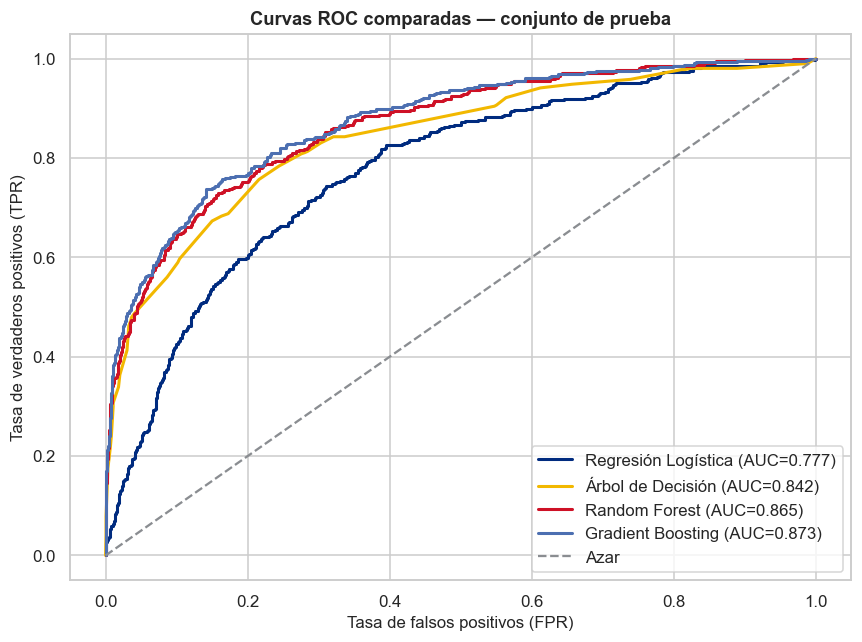

In [22]:
# Curvas ROC superpuestas
plt.figure(figsize=(8, 6))
for (nombre, modelo), color in zip(modelos.items(), PALETA):
    proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC={roc_auc_score(y_test, proba):.3f})')
plt.plot([0, 1], [0, 1], color=USM_GRIS, ls='--', label='Azar')
plt.xlabel('Tasa de falsos positivos (FPR)'); plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curvas ROC comparadas — conjunto de prueba')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

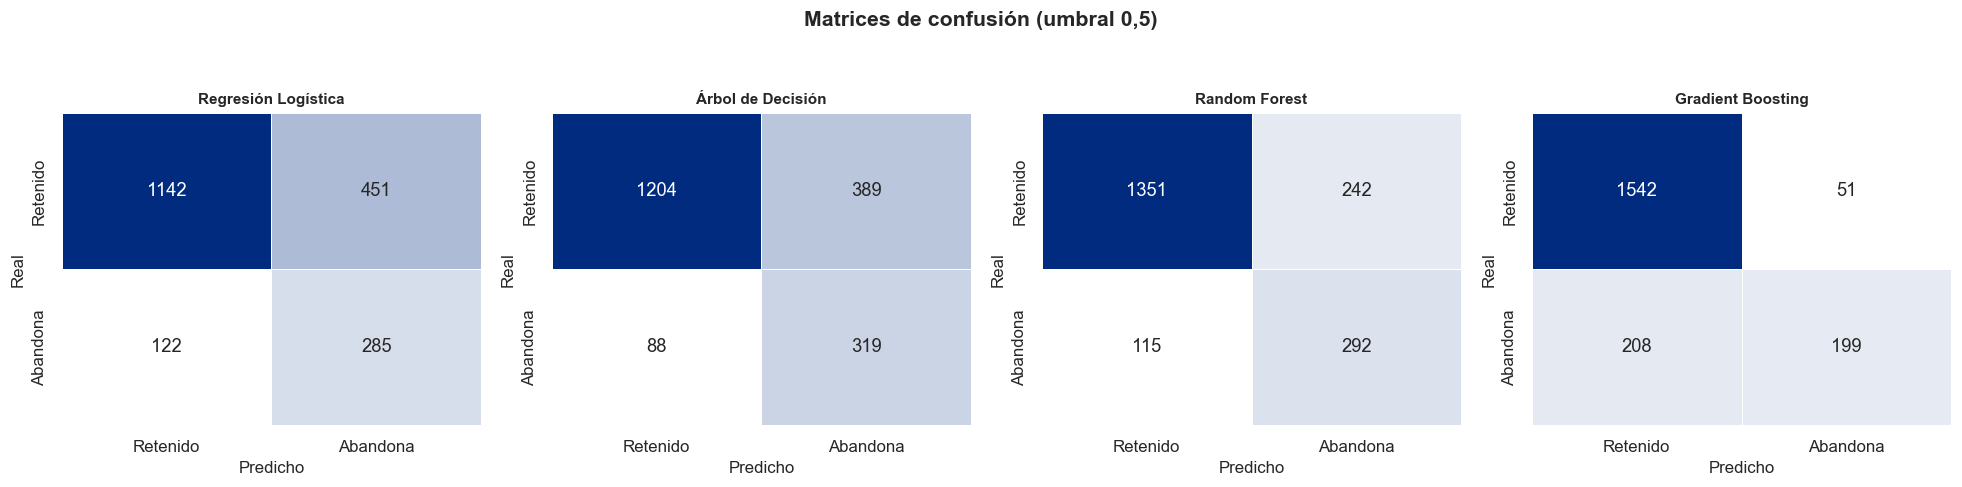

In [23]:
# Matrices de confusion de los cuatro modelos (umbral 0,5)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, (nombre, modelo) in zip(axes.ravel(), modelos.items()):
    pred = (modelo.predict_proba(X_test)[:, 1] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_seq, cbar=False, ax=ax, linewidths=.5,
                xticklabels=['Retenido', 'Abandona'], yticklabels=['Retenido', 'Abandona'])
    ax.set_title(nombre, fontsize=10); ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
plt.suptitle('Matrices de confusión (umbral 0,5)', y=1.05, fontsize=14)
plt.tight_layout(); plt.show()

### 5.2 Tabla comparativa

Aparece un patrón muy informativo. **Gradient Boosting** lidera en **ROC-AUC (0,873)** y **precisión (0,796)**, pero con umbral 0,5 tiene el **recall más bajo (0,49)**. La razón es metodológica: los otros tres modelos llevan `class_weight='balanced'`, que los vuelve "agresivos" prediciendo abandono (más recall, menos precisión), mientras que a Gradient Boosting **no le aplicamos ese peso** —lo tratamos por umbral—, así que con 0,5 es más conservador. Esto **no es un defecto**: su ROC-AUC superior indica que sus probabilidades están mejor ordenadas, de modo que podemos **subir su recall bajando el umbral** (Sección 6) sin sacrificar tanta precisión. Que los tres modelos de árbol superen al baseline lineal confirma la importancia de las relaciones no lineales del problema.

### 5.3 Selección del mejor modelo

Seleccionamos **Gradient Boosting** como modelo final:

1. **Mejor ROC-AUC (0,873)**, la métrica principal: mide la capacidad de discriminar entre quienes se van y quienes se quedan **a lo largo de todos los umbrales**, y es robusta frente al desbalance. Es el más alto de los cuatro.
2. **Mejor precisión (0,796)**: cuando alerta sobre un cliente en riesgo, acierta en ~80 % de los casos, minimizando el gasto de retención en falsas alarmas.
3. **Mayor margen de mejora**: aunque su recall con 0,5 es el más bajo, su AUC superior nos dice que ese recall puede **elevarse ajustando el umbral** (Sección 6) gracias a la calidad de sus probabilidades. La Regresión Logística, con el AUC más bajo (0,777), confirma que su naturaleza lineal no captura las relaciones clave del problema.

## 6. Umbral Óptimo y Balance entre Métricas de Negocio

### 6.1 Determinación del umbral óptimo

In [24]:
from sklearn.metrics import precision_recall_curve

mejor = modelos['Gradient Boosting']
proba = mejor.predict_proba(X_test)[:, 1]

prec, rec, thr = precision_recall_curve(y_test, proba)
f1_umbral = 2 * prec * rec / (prec + rec + 1e-12)
i_opt = int(np.argmax(f1_umbral[:-1]))
umbral_opt = thr[i_opt]
print(f'Umbral óptimo (maximiza F1): {umbral_opt:.3f}')
print(f'  Precisión = {prec[i_opt]:.3f} | Recall = {rec[i_opt]:.3f} | F1 = {f1_umbral[i_opt]:.3f}')

Umbral óptimo (maximiza F1): 0.233
  Precisión = 0.570 | Recall = 0.737 | F1 = 0.643


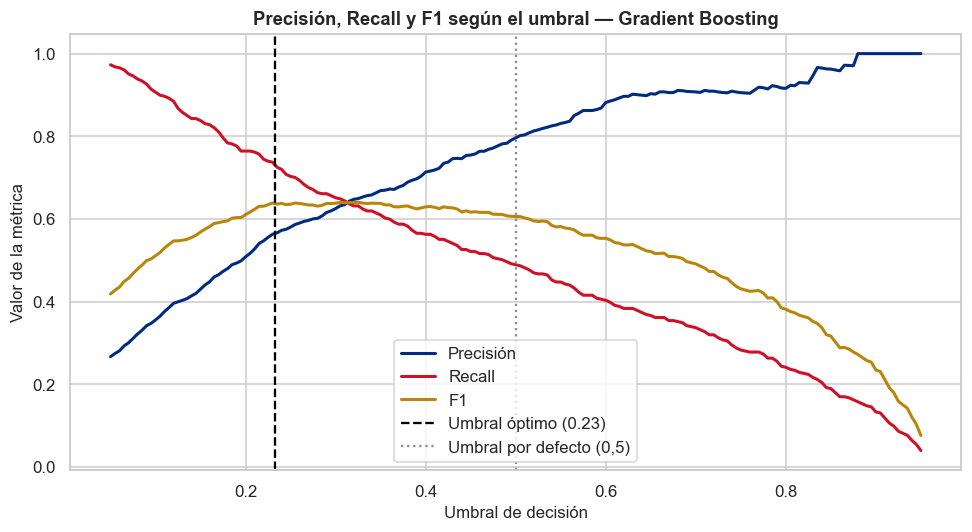

In [25]:
# Precision, Recall y F1 en funcion del umbral
umbrales = np.linspace(0.05, 0.95, 181)
P = [precision_score(y_test, (proba >= t).astype(int), zero_division=0) for t in umbrales]
R = [recall_score(y_test, (proba >= t).astype(int)) for t in umbrales]
F = [f1_score(y_test, (proba >= t).astype(int)) for t in umbrales]

plt.figure(figsize=(9, 5))
plt.plot(umbrales, P, color=USM_AZUL, lw=2, label='Precisión')
plt.plot(umbrales, R, color=USM_ROJO, lw=2, label='Recall')
plt.plot(umbrales, F, color=ORO_OSC, lw=2, label='F1')
plt.axvline(umbral_opt, color='black', ls='--', lw=1.5, label=f'Umbral óptimo ({umbral_opt:.2f})')
plt.axvline(0.5, color=USM_GRIS, ls=':', lw=1.5, label='Umbral por defecto (0,5)')
plt.xlabel('Umbral de decisión'); plt.ylabel('Valor de la métrica')
plt.title('Precisión, Recall y F1 según el umbral — Gradient Boosting')
plt.legend(); plt.tight_layout(); plt.show()

In [26]:
# Desempeno en umbrales representativos
filas = []
for t in [0.20, round(umbral_opt, 2), 0.30, 0.50, 0.70]:
    pred = (proba >= t).astype(int)
    filas.append({'Umbral': t,
                  'Precisión': precision_score(y_test, pred, zero_division=0),
                  'Recall': recall_score(y_test, pred),
                  'F1': f1_score(y_test, pred)})
pd.DataFrame(filas).set_index('Umbral').round(3)

,Precisión,Recall,F1
Umbral,,,
0.20,0.508,0.764,0.610
0.23,0.563,0.737,0.638
0.30,0.625,0.651,0.638
0.50,0.796,0.489,0.606
0.70,0.907,0.337,0.491


El umbral por defecto de 0,5 **rara vez es el óptimo** en problemas desbalanceados. Sobre las probabilidades del Gradient Boosting, barrimos una grilla de umbrales y elegimos el que **maximiza el F1** de la clase "abandona": resulta ser **0,23**, con precisión ≈ 0,57, recall ≈ 0,74 y F1 ≈ 0,64. Frente al 0,5, este punto **eleva el recall de 0,49 a 0,74** a cambio de una caída controlada de la precisión. Además, la curva de F1 es prácticamente **plana entre 0,23 y 0,30**, lo que nos da flexibilidad operativa para mover el umbral dentro de esa banda según el presupuesto de retención.

### 6.2 Comparación de desempeño bajo distintos umbrales

La figura y la tabla lo muestran con claridad: al **bajar** el umbral, el recall sube (capturamos más clientes en fuga) a costa de la precisión (más falsas alarmas); al **subirlo**, ocurre lo contrario. En 0,70 la precisión llega a 0,91 pero el recall cae a 0,34; en 0,20 el recall sube a 0,76 pero la precisión baja a 0,51. El óptimo de 0,23 equilibra ambos maximizando el F1.

### 6.3 Recall vs. Precisión: ¿qué le conviene a ABC Bank?

Para ABC Bank conviene **priorizar el Recall** (sin abandonar del todo la precisión). El razonamiento es de negocio: el error más costoso es el **falso negativo** —clasificar como "se queda" a un cliente que en realidad se va—, porque el banco pierde al cliente, todo su valor futuro y además debe pagar el alto costo de captar un reemplazo. Un **falso positivo** —alertar sobre alguien que se iba a quedar— solo cuesta una acción de retención (una llamada o un pequeño incentivo), un gasto mucho menor. Por eso operamos **por debajo de 0,5**, en torno a **0,23**, capturando a más clientes realmente en riesgo a cambio de algunos falsos positivos asumibles. El umbral exacto se calibra según el presupuesto: si es amplio, podemos bajarlo aún más; si es limitado, lo subimos para concentrar recursos en los casos de mayor probabilidad.

## 7. Análisis de Negocio y Recomendaciones

### 7.1 Factores más influyentes en el abandono

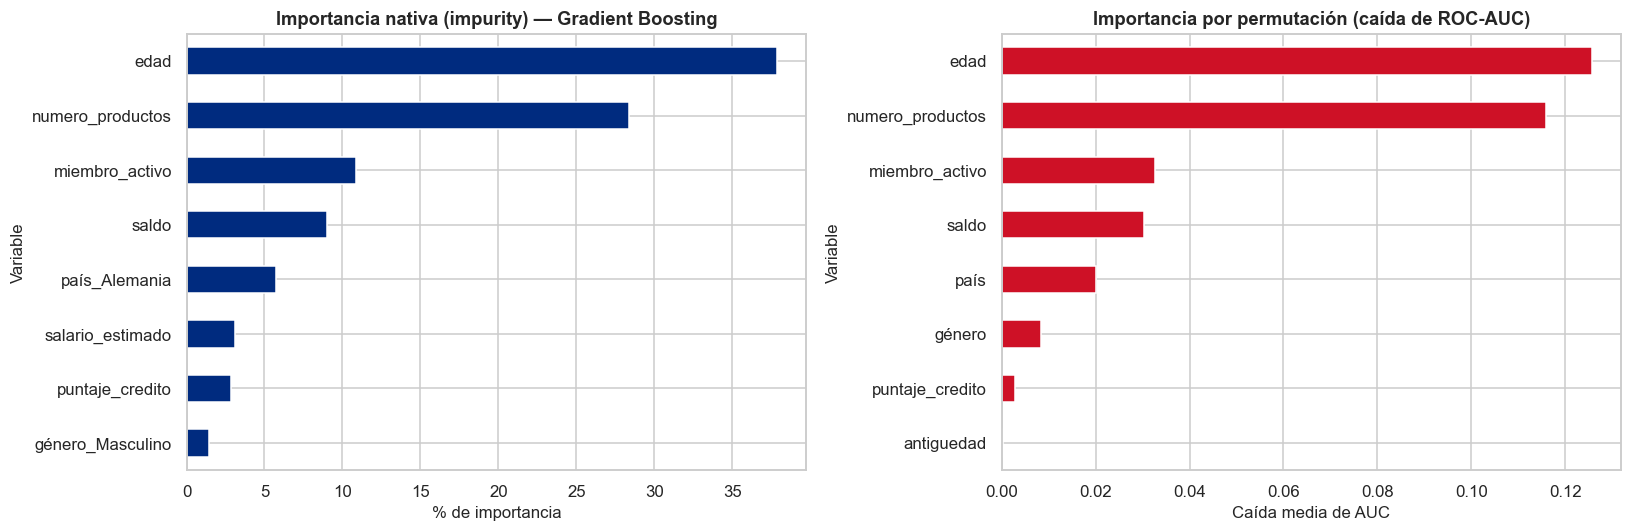

In [27]:
from sklearn.inspection import permutation_importance

# Importancia nativa del Gradient Boosting (por variable codificada)
feat = [f.split('__')[-1] for f in mejor.named_steps['prep'].get_feature_names_out()]
imp = pd.Series(mejor.named_steps['clf'].feature_importances_, index=feat)
imp_pct = (imp / imp.sum() * 100).sort_values()

# Importancia por permutacion (agrupa pais/genero y no depende del sesgo de impureza)
perm = permutation_importance(mejor, X_test, y_test, scoring='roc_auc',
                              n_repeats=10, random_state=RANDOM_STATE)
perm_s = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
imp_pct.tail(8).plot(kind='barh', ax=ax[0], color=USM_AZUL)
ax[0].set_title('Importancia nativa (impurity) — Gradient Boosting')
ax[0].set_xlabel('% de importancia'); ax[0].set_ylabel('Variable')
perm_s.tail(8).plot(kind='barh', ax=ax[1], color=USM_ROJO)
ax[1].set_title('Importancia por permutación (caída de ROC-AUC)')
ax[1].set_xlabel('Caída media de AUC'); ax[1].set_ylabel('Variable')
plt.tight_layout(); plt.show()

El Gradient Boosting revela que la decisión de fuga **no es aleatoria**: tres factores concentran cerca del **77 % de la importancia total**, y la importancia por permutación (más robusta) confirma exactamente el mismo ranking.

1. **Edad (~38 %):** el factor determinante. El segmento de mayor edad (promedio 44,8 años) tiene una propensión al abandono drásticamente superior a la del segmento joven.
2. **Número de productos (~28 %):** relación **fuertemente no lineal**. Con 2 productos el abandono es mínimo (7,6 %), pero escalar a 3 o 4 lo dispara a niveles críticos (**82,7 % y 100 %**). Es un síntoma claro de **fricción operativa** o de una estrategia de venta cruzada agresiva que genera insatisfacción.
3. **Actividad de la cuenta (~11 %):** los clientes inactivos abandonan casi al **doble** de velocidad que los activos, lo que subraya la importancia del *engagement* continuo.
4. **Factores secundarios (saldo ~9 % y geografía):** clientes con cuentas fondeadas (mayor saldo) y residentes en **Alemania (32,4 % de abandono** frente al ~16 % de Francia/España) presentan un riesgo significativamente mayor.

### 7.2 Acciones concretas por factor clave

Recomendamos que las áreas de Retención y Experiencia de Cliente (CX) implementen iniciativas focalizadas:

- **Segmento Senior (edad):** diseñar un modelo de **atención preferencial** para clientes mayores de 40 años —simplificar la interfaz en canales digitales, ofrecer asesoría financiera humana y estructurar productos de protección patrimonial o jubilación.
- **Auditoría de sobreventa (n.º de productos):** frenar el *cross-selling* agresivo sobre clientes que ya tienen 2 productos, y desplegar un equipo de retención para quienes tienen 3 o más que revise sus quejas, elimine comisiones ocultas o consolide su carga administrativa.
- **Campaña de *engagement* (inactividad):** un sistema de **alertas tempranas** —si un cliente no transacciona en 30 días, activar comunicaciones automáticas con beneficios de uso (p. ej. *cashback*) para reactivarlo antes de que cierre la cuenta.
- **Intervención en el mercado alemán:** hacer *benchmarking* contra competidores locales en Alemania para ajustar tasas o mejorar la oferta de valor que hoy está generando fuga.

### 7.3 Plan para reducir el abandono un 10 % el próximo trimestre

Proponemos un plan de contención de **90 días** en 4 pilares:

1. **Scoring mensual:** el día 1 de cada mes, pasamos el 100 % de la base activa por el modelo con el **umbral calibrado (0,23)** para identificar a los clientes en zona de riesgo.
2. **Matriz de priorización (riesgo × valor):** cruzamos la probabilidad de abandono con el saldo/salario del cliente y concentramos primero a los ejecutivos en el cuadrante de **alto riesgo y alto valor**.
3. **Despliegue táctico con prueba A/B:** lanzamos las acciones de 7.2 al **80 %** de los clientes en riesgo, dejando un **20 % como grupo de control**, para medir cuánta retención extra logramos gracias al modelo.
4. **Monitoreo de ROI:** comparamos el costo de los incentivos frente al capital retenido (valor de vida recuperado), demostrando que invertir en retención cuesta menos que el capital que se habría fugado.

### 7.4 Integración del modelo en una campaña de retención

Para que esto no quede en un análisis estático, **operacionalizamos** el modelo:

- **Conexión con el CRM:** automatizamos el pipeline para que la probabilidad de fuga se actualice **semanalmente** en el perfil de cada cliente; si supera el umbral (0,23), se genera un **ticket de "Alerta de Fuga"** para que un asesor actúe.
- **Ciclo de retroalimentación:** registramos el resultado de cada campaña (quién aceptó la oferta, quién se quedó, quién se fue igual). Esa información **realimenta al modelo**, permitiendo **reentrenarlo semestralmente** para que se adapte a los nuevos comportamientos del mercado.

## Resumen Ejecutivo

Ante el aumento de clientes que cierran sus cuentas en ABC Multistate Bank, construimos y comparamos **cuatro modelos de clasificación** para predecir el *churn* —fenómeno que afecta al **20,4 %** de una cartera de 10.000 clientes— y traducir esa predicción en acciones de retención. Tras un análisis exploratorio que identificó a la **edad**, el **número de productos** y la **inactividad** como las señales más fuertes de fuga, entrenamos los modelos dentro de *pipelines* sin fuga de datos, ajustamos sus hiperparámetros por validación cruzada optimizando ROC-AUC y tratamos el desbalance con ponderación de clases y calibración de umbral. El modelo seleccionado es **Gradient Boosting**, con el mejor **ROC-AUC de 0,87** y la mayor precisión, lo que le da el mejor equilibrio entre poder discriminativo y eficiencia del gasto de retención.

Nuestra recomendación a la dirección es **operar el modelo con un umbral de 0,23 en lugar de 0,5**, decisión que prioriza el *recall*: capturamos cerca del **74 % de los clientes que realmente abandonarán**, porque dejar escapar a un cliente (falso negativo) cuesta mucho más que una acción de retención innecesaria (falso positivo). En lo operativo, proponemos un plan de 90 días con **scoring mensual**, priorización por **riesgo × valor** e intervenciones focalizadas en los factores clave —atención preferencial al segmento senior, auditoría de la sobreventa de productos (con 3–4 productos el abandono escala al 82–100 %), campañas de reactivación para inactivos y una revisión de la oferta en **Alemania** (32,4 % de fuga)—, todo integrado al CRM con un ciclo de retroalimentación que reentrena el modelo semestralmente. Con este enfoque, la meta de **reducir el abandono un 10 % el próximo trimestre** es alcanzable y medible.